In [8]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
import tempfile

# ==========================================
# 0. Environment and Path Configuration
# ==========================================
# Defining a temporary directory for solver files to avoid permission issues
safe_temp_dir = r"D:\PyPSA_Temp" 

if not os.path.exists(safe_temp_dir):
    os.makedirs(safe_temp_dir)

os.environ['TMPDIR'] = safe_temp_dir
os.environ['TEMP'] = safe_temp_dir
os.environ['TMP'] = safe_temp_dir
tempfile.tempdir = safe_temp_dir

script_dir = os.getcwd()
os.chdir(script_dir)

In [9]:
# ==========================================
# 1. Initialize Network and Snapshots
# ==========================================
n = pypsa.Network()

# Hourly snapshots for a full year (8760 hours)
snapshots = pd.date_range("2017-01-01 00:00", "2017-12-31 23:00", freq="H")
n.set_snapshots(snapshots)

# ==========================================
# 2. Build Multi-node Topology (Buses)
# ==========================================
countries = ["DE", "FR", "AT", "CH"]

# Add buses with a nominal voltage of 400 kV
for c in countries:
    n.add("Bus", c, v_nom=400)

# ==========================================
# 3. Add Interconnectors (HVAC Lines)
# ==========================================
interconnectors = {
    "AT-CH": {"bus0": "AT", "bus1": "CH", "s_nom": 2152.75},
    "AT-DE": {"bus0": "AT", "bus1": "DE", "s_nom": 4232.10},
    "CH-DE": {"bus0": "CH", "bus1": "DE", "s_nom": 7106.32},
    "CH-FR": {"bus0": "CH", "bus1": "FR", "s_nom": 2926.94},
    "DE-FR": {"bus0": "DE", "bus1": "FR", "s_nom": 4120.00}
}

for name, params in interconnectors.items():
    n.add("Line", name,
          bus0=params["bus0"],
          bus1=params["bus1"],
          s_nom=params["s_nom"],           # Fixed interconnection capacity
          s_nom_extendable=False,          # Disable capacity expansion for cross-border lines
          x=0.1)                           # Key parameter: Per-unit reactance

D:\PyPSA_Temp\ipykernel_11680\2127493241.py:7: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



In [10]:
# ==========================================
# 4. Generator Configuration for Joint Optimization
# ==========================================
country_techs = {
    "DE": ["Wind Onshore", "Solar", "Fossil Hard coal", "Fossil Gas"], 
    "FR": ["Wind Onshore", "Solar", "Fossil Gas", "Nuclear"],
    "CH": ["Wind Onshore", "Solar", "Hydro Run-of-river and pondage", "Hydro Water Reservoir", "Hydro Pumped Storage"],
    "AT": ["Wind Onshore", "Solar", "Fossil Gas", "Hydro Run-of-river and pondage", "Hydro Water Reservoir", "Hydro Pumped Storage"]
}

costs = {
    "Wind Onshore": {"capital_cost": 103363.0, "marginal_cost": 0.01},
    "Solar": {"capital_cost": 49219.0, "marginal_cost": 0.01},
    "Fossil Gas": {"capital_cost": 66534.0, "marginal_cost": 55.38},      
    "Hydro Run-of-river and pondage": {"capital_cost": 270930.0, "marginal_cost": 0.01},
    "Hydro Water Reservoir": {"capital_cost": 160620.0, "marginal_cost": 0.01},
    "Fossil Hard coal": {"capital_cost": 135000.0, "marginal_cost": 40.0},
    "Nuclear": {"capital_cost": 450000.0, "marginal_cost": 12.0},
    "Hydro Pumped Storage": {"capital_cost": 160000.0, "marginal_cost": 2.0}
}

# List of Variable Renewable Energy Sources (VRES) requiring availability profiles (p_max_pu)
vres_techs = ["Wind Onshore", "Solar", "Hydro Run-of-river and pondage"]

def clean_datetime_index(df):
    if not isinstance(df.index, pd.DatetimeIndex):
        time_str = df.index.astype(str)
        # Handle time interval formats containing " - " (e.g., "00:00 - 01:00")
        if time_str.str.contains(' - ').any():
            time_str = time_str.str.split(' - ').str[0]
        # Remove timezone suffixes like " (CET)" or " (CEST)"
        time_str = time_str.str.replace(r'\s*\(.*?\)', '', regex=True)
        # Force parsing using "Day/Month/Year" format
        df.index = pd.to_datetime(time_str, dayfirst=True)
    return df

# Iterate through countries to populate data
for c in countries:
    # 1. Import and process load data
    df_path = os.path.join(script_dir, f"{c}_Load_d).csv") # Ensure filename matches local file naming convention
    load_df = pd.read_csv(df_path, index_col=0)
    load_df = clean_datetime_index(load_df)
    
    # Clean numeric format (remove commas and convert to float)
    load_series = load_df['Actual Total Load (MW)'].astype(str).str.replace(',', '')
    load_series = pd.to_numeric(load_series, errors='coerce')

    # Resample to hourly and align with network snapshots
    hourly_load = load_series.resample('1h').mean()
    hourly_load = hourly_load.reindex(n.snapshots).fillna(0) 

    n.add("Load", f"{c}_load",
          bus=c,
          p_set=hourly_load.values)
    
    # 2. Import generation data and convert to generator units
    df_path = os.path.join(script_dir, f"{c}_Gene_d).csv")
    gene_df = pd.read_csv(df_path, index_col=0) 
    gene_df = clean_datetime_index(gene_df)
    
    for tech in country_techs[c]:
        cost = costs[tech]
        
        tech_df = gene_df[gene_df['Production Type'] == tech]

def clean_datetime_index(df):
    if not isinstance(df.index, pd.DatetimeIndex):
        time_str = df.index.astype(str)
        # Handle time interval formats containing " - " (e.g., "00:00 - 01:00")
        if time_str.str.contains(' - ').any():
            time_str = time_str.str.split(' - ').str[0]
        # Remove timezone suffixes like " (CET)" or " (CEST)"
        time_str = time_str.str.replace(r'\s*\(.*?\)', '', regex=True)
        # Force parsing using "Day/Month/Year" format
        df.index = pd.to_datetime(time_str, dayfirst=True)
    return df

# Iterate through countries to populate data
for c in countries:
    # 1. Import and process load data
    df_path = os.path.join(script_dir, f"{c}_Load_d).csv") # Ensure filename matches local file naming convention
    load_df = pd.read_csv(df_path, index_col=0)
    load_df = clean_datetime_index(load_df)
    
    # Clean numeric format (remove commas and convert to float)
    load_series = load_df['Actual Total Load (MW)'].astype(str).str.replace(',', '')
    load_series = pd.to_numeric(load_series, errors='coerce')

    # Resample to hourly and align with network snapshots
    hourly_load = load_series.resample('1h').mean()
    hourly_load = hourly_load.reindex(n.snapshots).fillna(0) 

    n.add("Load", f"{c}_load",
          bus=c,
          p_set=hourly_load.values)
    
    # 2. Import generation data and convert to generator units
    df_path = os.path.join(script_dir, f"{c}_Gene_d).csv")
    gene_df = pd.read_csv(df_path, index_col=0) 
    gene_df = clean_datetime_index(gene_df)
    
    for tech in country_techs[c]:
        cost = costs[tech]
        
        tech_df = gene_df[gene_df['Production Type'] == tech]
        
        if tech_df.empty:
            print(f"⚠️ Warning: No valid generation data found for {tech} in {c} within the CSV.")
            continue
            
        # Also force conversion to numeric format
        gen_series = tech_df['Generation (MW)'].astype(str).str.replace(',', '')
        gen_series = pd.to_numeric(gen_series, errors='coerce')

        tech_gen = gen_series.resample('1h').mean()
        tech_gen = tech_gen.reindex(n.snapshots).fillna(0)
        
        if tech_gen.max() == 0:
            print(f"⚠️ Warning: Annual generation data for {tech} in {c} is zero.")
            continue
            
        # A. Variable Renewable Energy Sources (VRES)
        if tech in vres_techs:
            # Create availability profile (p_max_pu)
            p_max_pu_profile = tech_gen / tech_gen.max()
            p_max_pu_profile = np.clip(p_max_pu_profile.values, 0, 1) 
            
            n.add("Generator", f"{c}_{tech}",
                  bus=c,
                  carrier=tech,
                  p_nom_extendable=True,
                  p_max_pu=p_max_pu_profile,
                  capital_cost=cost["capital_cost"],
                  marginal_cost=cost["marginal_cost"])
                  
        # B. Pumped Hydro Storage (modeled as StorageUnit)
        elif tech == "Hydro Pumped Storage":
            n.add("StorageUnit", f"{c}_{tech}",
                  bus=c,
                  carrier=tech,
                  p_nom_extendable=True,
                  capital_cost=cost["capital_cost"],
                  marginal_cost=cost["marginal_cost"],
                  efficiency_store=0.8,     
                  efficiency_dispatch=0.9,  
                  max_hours=6)              
                  
        # C. Conventional Dispatchable Generators
        else:
            n.add("Generator", f"{c}_{tech}",
                  bus=c,
                  carrier=tech,
                  p_nom_extendable=True,
                  capital_cost=cost["capital_cost"],
                  marginal_cost=cost["marginal_cost"])

# ==========================================
# 5. Run DC Optimal Power Flow (DC OPF)
# ==========================================
print("✅ Model construction complete, including the following components:")
print(n.components)
print("\nSystem ready. Starting joint optimization solver...")

D:\PyPSA_Temp\ipykernel_11680\3262346694.py:58: DtypeWarning:

Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.

D:\PyPSA_Temp\ipykernel_11680\3262346694.py:99: DtypeWarning:

Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.



✅ Model construction complete, including the following components:
PyPSA Components Store
- 4 'Bus' Components
- 0 'Carrier' Components
- 17 'Generator' Components
- 4 'Load' Components
- 0 'Link' Components
- 0 'Store' Components
- 2 'StorageUnit' Components
- 5 'Line' Components
- 59 'LineType' Components
- 0 'Transformer' Components
- 14 'TransformerType' Components
- 0 'ShuntImpedance' Components
- 0 'GlobalConstraint' Components
- 0 'Shape' Components
- 0 'SubNetwork' Components

System ready. Starting joint optimization solver...


In [11]:
# ==========================================
# 任务 g) 插入位置：在此定义 CH4 网络组件
# ==========================================

Task g) Define CH4 Network
n.add("Carrier", "CH4")
for c in countries:
    n.add("Bus", f"{c} CH4", carrier="CH4")

# 2. Introduce natural gas benchmark price (17.3 €/MWh)
for c in countries:
    n.add("Generator", f"{c} Gas Market",
          bus=f"{c} CH4",
          carrier="CH4",
          p_nom_extendable=True,
          marginal_cost=17.3)

# 3. Add cross-border natural gas pipelines
for name, params in interconnectors.items():
    n.add("Link", f"{name} CH4 Pipeline",
          bus0=f"{params['bus0']} CH4",
          bus1=f"{params['bus1']} CH4",
          p_nom_extendable=True,
          p_min_pu=-1)

# 4. Establish sector coupling (Power-to-Gas and OCGT)
for c in countries:
    n.add("Link", f"{c} Power-to-Gas",
          bus0=c,              
          bus1=f"{c} CH4",     
          p_nom_extendable=True,
          efficiency=0.6,      
          capital_cost=75000)  
          
    n.add("Link", f"{c} OCGT",
          bus0=f"{c} CH4",     
          bus1=c,              
          p_nom_extendable=True,
          efficiency=0.39, 
          capital_cost=66534.0*0.39)  

In [12]:
# ==========================================
# Operational Optimization
# ==========================================
status, condition = n.optimize(solver_name="gurobi") # Change solver_name if using open-source solvers like glpk or cbc
print(f"Optimization Status: {status}")

if status == "ok":
    print("\n--- Optimized Interconnector Configuration and Loading Factors ---")
    # Calculate the average loading rate of the lines
    loading = (n.lines_t.p0.abs().mean() / n.lines.s_nom) * 100
    print(loading.round(2).astype(str) + " %")

Index(['DE', 'FR', 'AT', 'CH'], dtype='object', name='name')
Index(['DE_Wind Onshore', 'DE_Solar', 'DE_Fossil Hard coal', 'DE_Fossil Gas',
       'FR_Wind Onshore', 'FR_Solar', 'FR_Fossil Gas', 'FR_Nuclear',
       'AT_Wind Onshore', 'AT_Solar', 'AT_Fossil Gas',
       'AT_Hydro Run-of-river and pondage', 'AT_Hydro Water Reservoir',
       'CH_Wind Onshore', 'CH_Solar', 'CH_Hydro Run-of-river and pondage',
       'CH_Hydro Water Reservoir'],
      dtype='object', name='name')
Index(['DE Power-to-Gas', 'FR Power-to-Gas', 'AT Power-to-Gas',
       'CH Power-to-Gas'],
      dtype='object', name='name')
Index(['AT_Hydro Pumped Storage', 'CH_Hydro Pumped Storage'], dtype='object', name='name')
Index(['AT-CH', 'AT-DE', 'CH-DE', 'CH-FR', 'DE-FR'], dtype='object', name='name')
Index(['AT-CH', 'AT-DE', 'CH-DE', 'CH-FR', 'DE-FR'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 9/9

Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2773773


INFO:gurobipy:Set parameter LicenseID to value 2773773


...

Solved in 116522 iterations and 18.29 seconds (14.02 work units)


INFO:gurobipy:Solved in 116522 iterations and 18.29 seconds (14.02 work units)


Optimal objective  5.595494554e+10


INFO:gurobipy:Optimal objective  5.595494554e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 394236 primals, 893556 duals
Objective: 5.60e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.


Optimization Status: ok

--- Optimized Interconnector Configuration and Loading Factors ---
name
AT-CH    94.85 %
AT-DE    97.98 %
CH-DE    86.69 %
CH-FR    96.55 %
DE-FR    81.69 %
dtype: object


In [13]:
# ==========================================
# 6. Data Extraction (Preparation for subsequent sections)
# ==========================================
if status == "ok":
    print("\n--- Overview of the total power flow of the interconnected lines ---")
    print(n.lines_t.p0.describe())
    
    print("\n--- Optimized generator capacity of each node (in MW) ---")
    print(n.generators.p_nom_opt)
    
    # Get the power flow at the first time step; this is the benchmark for manual PTDF verification in part e)
    print("\n--- Line power at the first time step (MW) ---")
    first_step_flows = n.lines_t.p0.iloc[0]
    print(first_step_flows)
    
    # Save nodal power imbalances (Generation - Demand) at the first time step for part e)
    first_step_imbalance = (n.generators_t.p.iloc[0].groupby(n.generators.bus).sum() 
                            - n.loads_t.p_set.iloc[0].groupby(n.loads.bus).sum())
    print("\n--- Nodal power injection/imbalance at the first time step (MW) ---")
    print(first_step_imbalance)

    # =========================================
    # Supplementary print: View the optimized capacities of Link components (pipelines and conversion facilities)
    # =========================================
    print("\n--- Optimized Link capacities (in MW) ---")
    # Filter out original power grid data, focusing only on the relevant pipelines, P2G, and OCGT
    gas_links = n.links[n.links.index.str.contains("Pipeline|Power-to-Gas|OCGT")]
    print(gas_links.p_nom_opt)

    # =========================================
    # Supplementary print: Comparison of energy transport required for Task g)
    # =========================================
    print("\n--- Task g) Energy Transport Comparison ---")
    # Extract total transport volume of AC transmission lines (MWh)
    total_electricity_transported = n.lines_t.p0.abs().sum().sum()

    # Extract total transport volume of cross-border natural gas pipelines (MWh)
    pipeline_links = n.links.index[n.links.index.str.contains("CH4 Pipeline")]
    total_gas_transported = n.links_t.p0[pipeline_links].abs().sum().sum()

    print(f"Total Electricity Transported: {total_electricity_transported / 1e6:.2f} TWh")
    print(f"Total Gas (CH4) Transported:   {total_gas_transported / 1e6:.2f} TWh")


--- Overview of the total power flow of the interconnected lines ---
name         AT-CH        AT-DE        CH-DE        CH-FR        DE-FR
count  8760.000000  8760.000000  8760.000000  8760.000000  8760.000000
mean  -2013.679983  4144.491853  6158.171835  2816.241641 -3341.930195
std     433.312823   460.979850   690.968540   358.170631   697.195727
min   -2152.750000  -941.197885 -1193.060000 -2926.940000 -4120.000000
25%   -2152.750000  4232.100000  6270.126250  2926.940000 -3457.910000
50%   -2152.750000  4232.100000  6384.850000  2926.940000 -3457.910000
75%   -2099.016250  4232.100000  6384.850000  2926.940000 -3357.195546
max    2152.750000  4232.100000  6384.850000  2926.940000  4120.000000

--- Optimized generator capacity of each node (in MW) ---
name
DE_Wind Onshore                      47628.534760
DE_Solar                             46410.755669
DE_Fossil Hard coal                  23917.824823
DE_Fossil Gas                        39000.697532
FR_Wind Onshore            

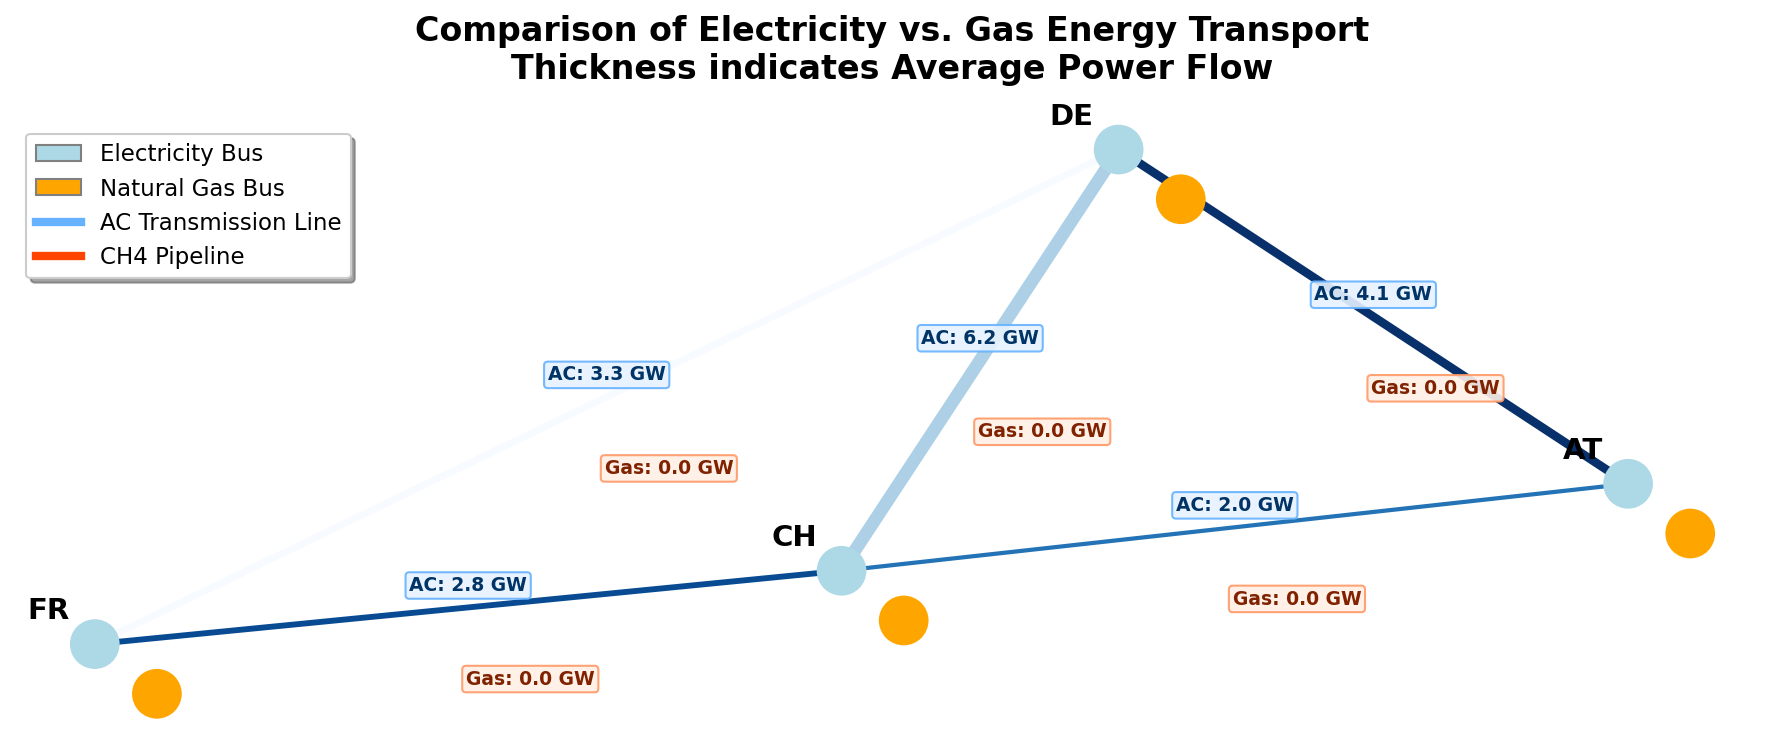

In [14]:
# ==========================================
# 1. Set bus coordinates (Core trick: slightly offset gas network coordinates)
# ==========================================
countries = ["DE", "FR", "CH", "AT"]
coords = {"DE": [10.45, 50.2], "FR": [2.21, 46.22], "CH": [8.22, 46.81], "AT": [14.55, 47.51]}

# Set power grid bus coordinates
for c in countries:
    n.buses.loc[c, ["x", "y"]] = coords[c]

# Set natural gas bus coordinates (offset to the bottom right to avoid overlap)
offset_x, offset_y = 0.5, -0.4
for c in countries:
    # Ensure your gas network bus names are "XX CH4"; if set differently earlier, adjust accordingly
    if f"{c} CH4" in n.buses.index: 
        n.buses.loc[f"{c} CH4", ["x", "y"]] = [coords[c][0] + offset_x, coords[c][1] + offset_y]

# ==========================================
# 2. Extract transmission data and set visual parameters
# ==========================================
# Power grid data (Lines)
ac_mean_flow = n.lines_t.p0.mean().abs()
# If you allow line capacity expansion, use s_nom_opt to calculate loading; if fixed capacity, use s_nom
ac_loading = (ac_mean_flow / n.lines.s_nom_opt) * 100 

# Gas network data (Pipelines in Links)
pipeline_links = n.links.index[n.links.index.str.contains("Pipeline")]
gas_mean_flow = n.links_t.p0[pipeline_links].mean().abs()

# Set bus colors (Electricity: light blue, Gas: orange)
bus_colors = pd.Series("lightblue", index=n.buses.index)
bus_colors[n.buses.index.str.contains("CH4")] = "#FFA500" # Orange

# Set line widths (scale by the same proportion to reflect actual transmission differences, adjust the denominator based on your actual values)
scale_factor = 1000 
line_widths = ac_mean_flow / scale_factor

link_widths = pd.Series(0.0, index=n.links.index)
link_widths[pipeline_links] = gas_mean_flow / scale_factor

# Set pipeline colors (Natural gas pipelines set to red)
link_colors = pd.Series("lightgray", index=n.links.index)
link_colors[pipeline_links] = "#FF4500" # OrangeRed

# ==========================================
# 3. Plot the network
# ==========================================
fig, ax = plt.subplots(figsize=(12, 9), dpi=150) # Increase resolution

n.plot(
    ax=ax,
    bus_sizes=0.04,                        
    bus_colors=bus_colors,                
    line_colors=ac_loading,                   
    line_cmap=plt.cm.Blues,  # Use blue colormap to indicate power grid congestion               
    line_widths=line_widths,
    link_colors=link_colors,
    link_widths=link_widths,
    title="Comparison of Electricity (AC) vs. Natural Gas (CH4) Energy Transport"
)

# Optimize title
plt.title("Comparison of Electricity vs. Gas Energy Transport\nThickness indicates Average Power Flow", 
          y=1.02, fontsize=16, fontweight='bold', pad=15)

# ==========================================
# 4. Add elegant text labels (annotate actual flows)
# ==========================================
# Add average transmission labels to the power grid (blue boxes)
for line_name, line in n.lines.iterrows():
    bus0, bus1 = n.buses.loc[line.bus0], n.buses.loc[line.bus1]
    x_pos, y_pos = (bus0.x + bus1.x) / 2, (bus0.y + bus1.y) / 2 + 0.1
    flow_gw = ac_mean_flow[line_name] / 1000 # Convert to GW
    
    ax.text(x_pos, y_pos, f"AC: {flow_gw:.1f} GW", 
            fontsize=9, fontweight='bold', color='#003366', ha='center', va='bottom', 
            bbox=dict(facecolor='#E6F2FF', alpha=0.9, edgecolor='#66B2FF', boxstyle='round,pad=0.2'))

# Add average transmission labels to the gas network (orange boxes)
for link_name in pipeline_links:
    link = n.links.loc[link_name]
    bus0, bus1 = n.buses.loc[link.bus0], n.buses.loc[link.bus1]
    x_pos, y_pos = (bus0.x + bus1.x) / 2, (bus0.y + bus1.y) / 2 - 0.1
    flow_gw = gas_mean_flow[link_name] / 1000 # Convert to GW
    
    ax.text(x_pos, y_pos, f"Gas: {flow_gw:.1f} GW", 
            fontsize=9, fontweight='bold', color='#802200', ha='center', va='top', 
            bbox=dict(facecolor='#FFF0E6', alpha=0.9, edgecolor='#FF9966', boxstyle='round,pad=0.2'))

# Add country labels
for bus_name, bus in n.buses.iterrows():
    if "CH4" not in bus_name: # Only label country names on power grid nodes to avoid duplication
        ax.text(bus.x - 0.2, bus.y + 0.2, bus_name, fontsize=14, fontweight='bold', ha='right')

# ==========================================
# 5. Add custom legend
# ==========================================
legend_elements = [
    mpatches.Patch(facecolor='lightblue', edgecolor='gray', label='Electricity Bus'),
    mpatches.Patch(facecolor='#FFA500', edgecolor='gray', label='Natural Gas Bus'),
    plt.Line2D([0], [0], color='#66B2FF', lw=4, label='AC Transmission Line'),
    plt.Line2D([0], [0], color='#FF4500', lw=4, label='CH4 Pipeline')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=11, frameon=True, shadow=True)

ax.axis('off')
plt.tight_layout()
plt.show()